In [75]:
import  numpy as np
import pandas  as  pd
import matplotlib.pyplot as  plt
import seaborn as sns
from sklearn.cluster import KMeans

In [19]:
customer_dataset = pd.read_csv(r"C:\Users\MY LAPTOP\OneDrive\Desktop\Machine_Learning\Customer Segmentation\Mall_Customers.csv")

In [20]:
customer_dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [29]:
customer_dataset.rename(columns={
    'Annual Income (k$)' : 'Income',
    'Spending Score (1-100)' : 'Score'
}, inplace=True)

In [21]:
customer_dataset.shape

(200, 5)

In [22]:
customer_dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [23]:
customer_dataset.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [24]:
customer_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [25]:
customer_dataset.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [26]:
customer_dataset.drop(['CustomerID'], axis=1, inplace=True)
customer_dataset.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


C:\Users\MY LAPTOP\AppData\Local\Temp\ipykernel_1152\2082684983.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_dataset[x], bins=20)
C:\Users\MY LAPTOP\AppData\Local\Temp\ipykernel_1152\2082684983.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_dataset[x], bins=20)
C:\U

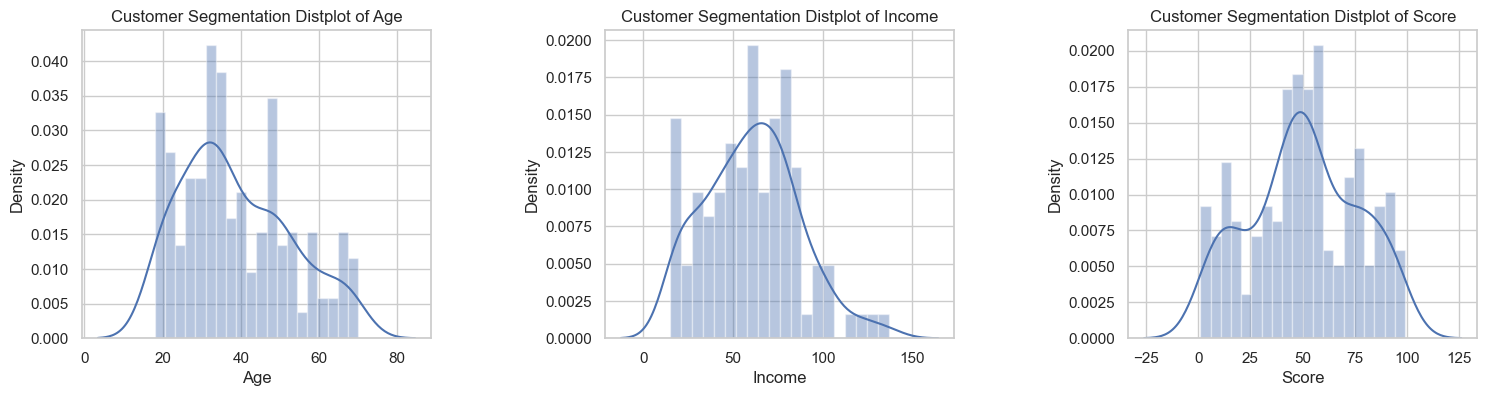

In [52]:
plt.figure(1, figsize=(18,4))
n = 0
for x in ['Age', 'Income', 'Score']:
    n += 1
    plt.subplot(1, 3, n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.distplot(customer_dataset[x], bins=20)
    plt.title('Customer Segmentation Distplot of {}'.format(x))
plt.show()

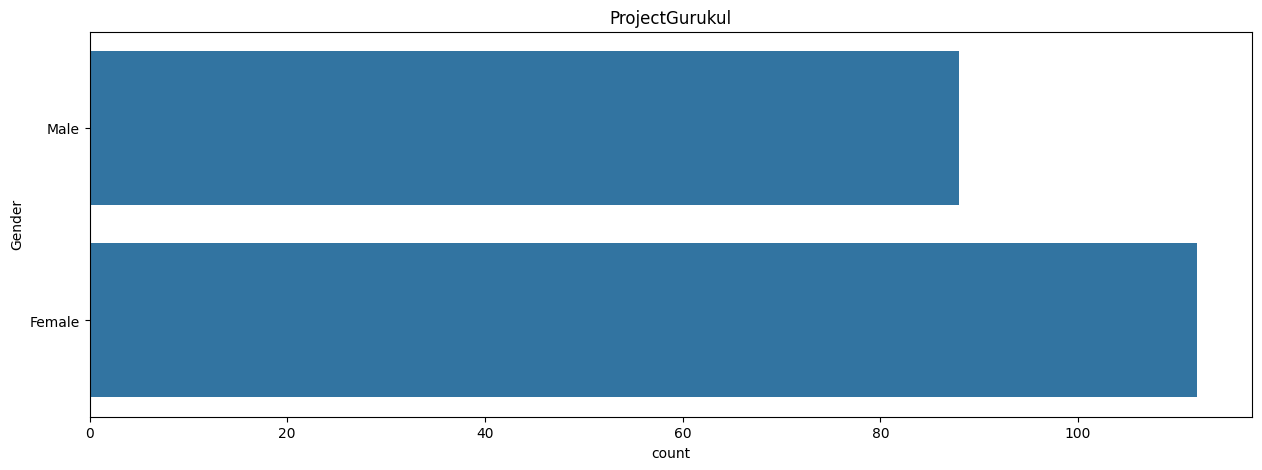

In [40]:
plt.figure(figsize=(15,5))
sns.countplot(y = 'Gender' , data = customer_dataset)
plt.title('ProjectGurukul')
plt.show()

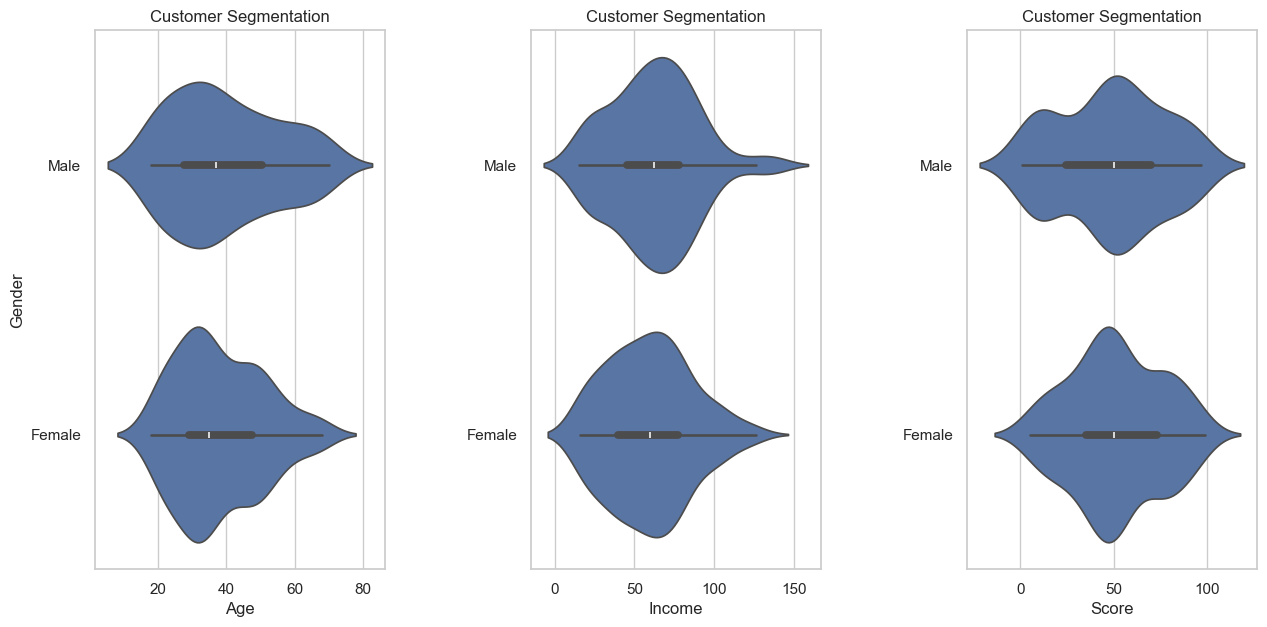

In [54]:
plt.figure(1,figsize=(15,7))
n = 0 
for cols in ['Age', 'Income', 'Score']:
    n += 1
    plt.subplot(1, 3, n)
    sns.set(style='whitegrid')
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.violinplot(x=cols, y='Gender', data=customer_dataset)
    plt.ylabel('Gender'if n==1 else '')
    plt.title('Customer Segmentation')

plt.show()

C:\Users\MY LAPTOP\AppData\Local\Temp\ipykernel_1152\1768778979.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agex, y=agey, palette='mako')


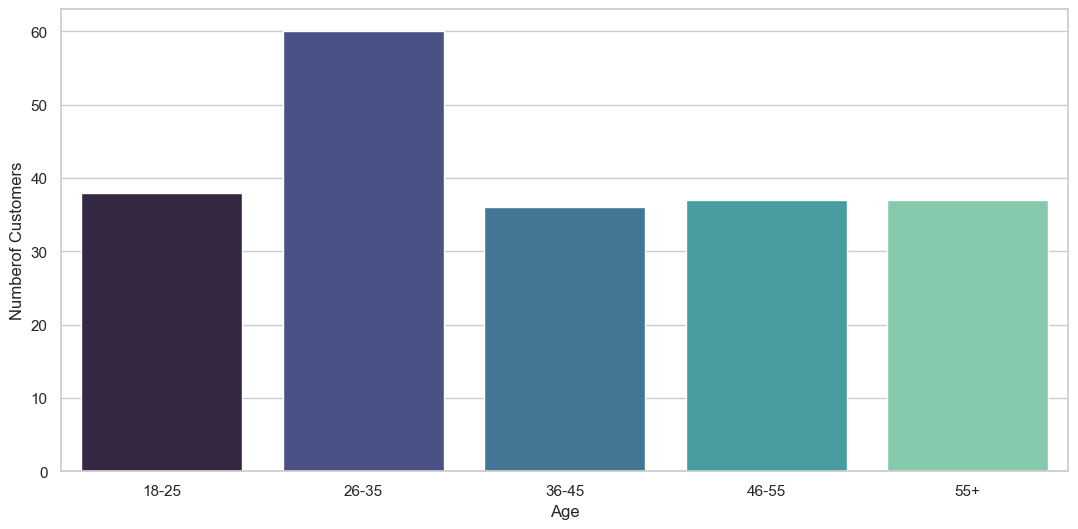

In [62]:
age_18_25 = customer_dataset.Age[(customer_dataset.Age >= 18) & (customer_dataset.Age <= 25)]
age_26_35 = customer_dataset.Age[(customer_dataset.Age >= 26) & (customer_dataset.Age <= 35)]
age_36_45 = customer_dataset.Age[(customer_dataset.Age >= 36) & (customer_dataset.Age <= 45)]
age_46_55 = customer_dataset.Age[(customer_dataset.Age >= 46) & (customer_dataset.Age <= 55)]
age_above_55 = customer_dataset.Age[(customer_dataset.Age >= 46) & (customer_dataset.Age <=55)]

agex = ['18-25', '26-35', '36-45', '46-55', '55+']
agey = [len(age_18_25.values), len(age_26_35.values), len(age_36_45.values), len(age_46_55.values), len(age_above_55.values)]

plt.figure(figsize=(13,6))
sns.barplot(x=agex, y=agey, palette='mako')
plt.xlabel('Age')
plt.ylabel('Numberof Customers')
plt.show()

C:\Users\MY LAPTOP\AppData\Local\Temp\ipykernel_1152\1061907153.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ssx, y=ssy, palette='rocket')


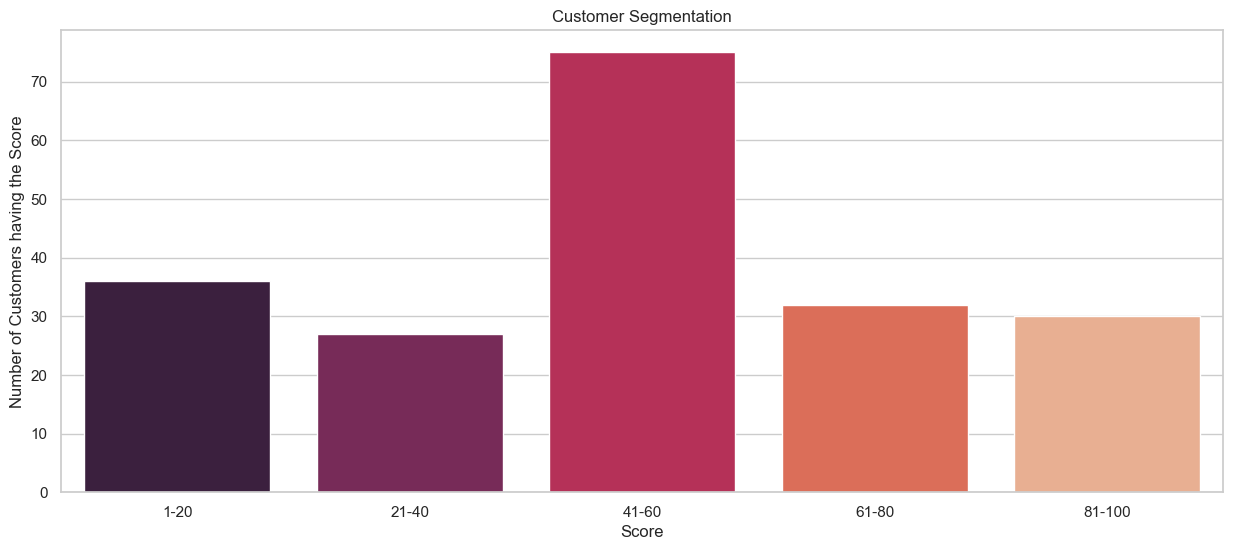

In [68]:
ssx = ['1-20', '21-40', '41-60', '61-80', '81-100']

ssy = [
    len(customer_dataset[(customer_dataset['Score'] >= 1) & (customer_dataset['Score'] <= 20)]),
    len(customer_dataset[(customer_dataset['Score'] >= 21) & (customer_dataset['Score'] <= 40)]),
    len(customer_dataset[(customer_dataset['Score'] >= 41) & (customer_dataset['Score'] <= 60)]),
    len(customer_dataset[(customer_dataset['Score'] >= 61) & (customer_dataset['Score'] <= 80)]),
    len(customer_dataset[(customer_dataset['Score'] >= 81) & (customer_dataset['Score'] <= 100)])
]

plt.figure(figsize=(15,6))
sns.barplot(x=ssx, y=ssy, palette='rocket')
plt.title('Customer Segmentation')
plt.xlabel('Score')
plt.ylabel('Number of Customers having the Score')
plt.show()

C:\Users\MY LAPTOP\AppData\Local\Temp\ipykernel_1152\3375174061.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=annx, y=anny, palette='Spectral')


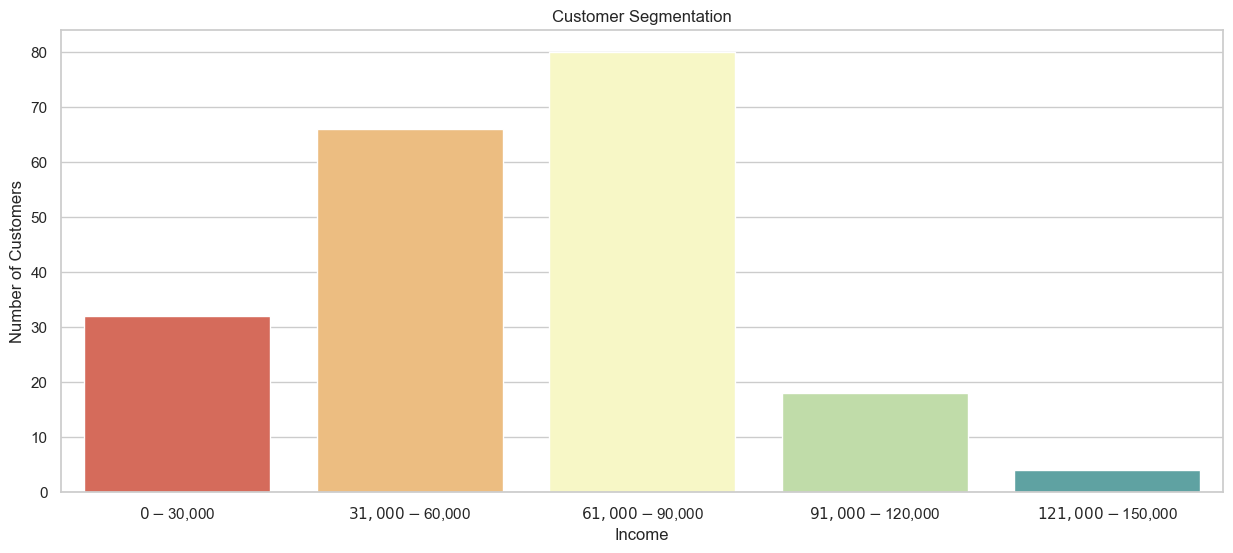

In [72]:
annx = ['$0 -$30,000', '$31,000 - $60,000', '$61,000 - $90,000', '$91,000 - $120,000', '$121,000 - $150,000']

anny = [
    len(customer_dataset['Income'][(customer_dataset['Income'] >= 0 ) & (customer_dataset['Income'] <= 30)].values),
    len(customer_dataset['Income'][(customer_dataset['Income'] >= 31 ) & (customer_dataset['Income'] <= 60)].values),
    len(customer_dataset['Income'][(customer_dataset['Income'] >= 61 ) & (customer_dataset['Income'] <= 90)].values),
    len(customer_dataset['Income'][(customer_dataset['Income'] >= 91 ) & (customer_dataset['Income'] <= 120)].values),
    len(customer_dataset['Income'][(customer_dataset['Income'] >= 121 ) & (customer_dataset['Income'] <= 150)].values)
]

plt.figure(figsize=(15,6))
sns.barplot(x=annx, y=anny, palette='Spectral')
plt.title('Customer Segmentation')
plt.xlabel('Income')
plt.ylabel('Number of Customers')
plt.show()

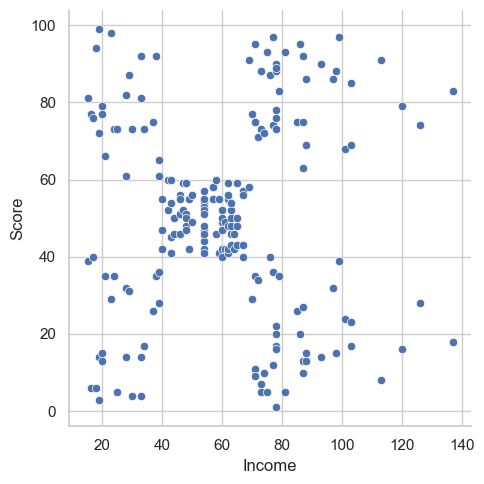

In [74]:
sns.relplot(x='Income', y='Score', data=customer_dataset)

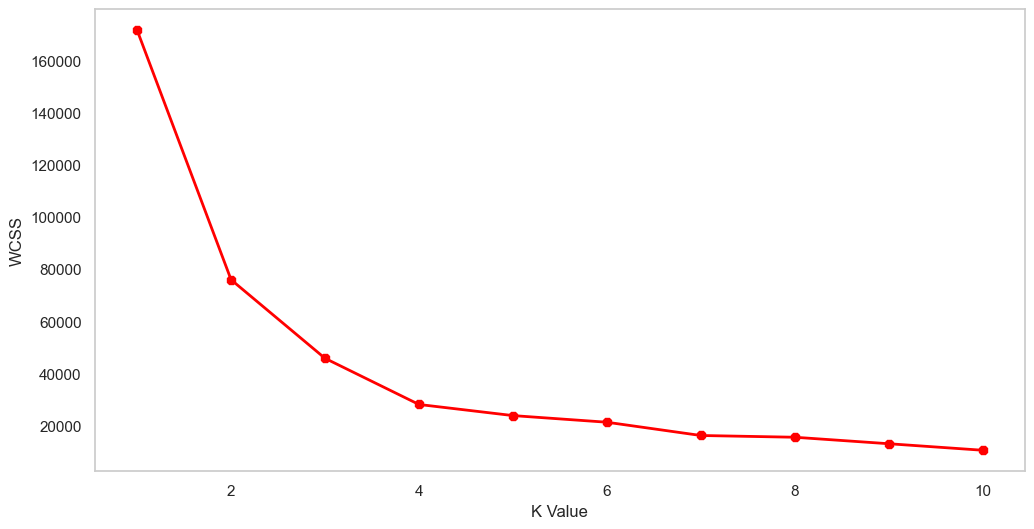

In [82]:
X1 = customer_dataset.loc[:, ['Age', 'Score']].values
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X1)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12,6))
plt.grid()
plt.plot(range(1, 11), wcss, linewidth=2, color='red', marker='8')
plt.xlabel('K Value')
plt.ylabel('WCSS')
plt.show()

[3 1 0 1 3 1 0 5 4 1 4 5 4 1 0 1 9 7 9 5 9 1 8 1 4 1 9 7 9 5 4 1 4 5 8 1 8
 1 9 1 6 5 9 7 9 7 2 3 3 3 2 7 7 6 2 9 2 6 7 2 6 7 6 2 6 7 2 6 7 3 6 2 6 6
 6 7 2 2 7 2 6 2 6 2 7 2 2 7 7 2 6 3 2 9 3 7 2 7 2 7 3 2 6 7 2 3 6 2 6 6 6
 7 9 3 3 7 6 2 2 2 7 9 2 5 3 1 9 5 4 1 8 1 3 1 0 5 8 1 0 1 4 5 3 5 0 5 9 1
 0 5 8 5 8 1 8 5 0 1 0 1 9 5 0 5 9 1 8 5 9 7 8 1 0 5 8 5 4 1 4 5 9 5 8 5 9
 5 8 1 8 5 0 1 0 5 8 1 9 1 0 5]
[[29.64285714 10.        ]
 [29.1        74.83333333]
 [48.19230769 49.84615385]
 [25.06666667 41.33333333]
 [58.9         9.9       ]
 [31.37037037 90.7037037 ]
 [64.85       49.85      ]
 [25.08695652 56.43478261]
 [45.6        14.86666667]
 [42.95       33.65      ]]


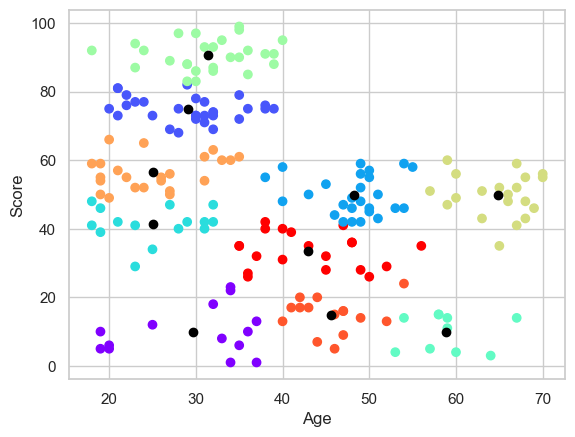

In [84]:
kmans = KMeans(n_clusters=4)
label = kmeans.fit_predict(X1)

print(label)
print(kmeans.cluster_centers_)

plt.scatter(X1[:, 0], X1[:,1], c=kmeans.labels_, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black')
plt.xlabel('Age')
plt.ylabel('Score')
plt.show()